# Daniyal Khan || 221A061 || 19

In [1]:
# Daniyal Khan || 221A061
!pip install youtube-comment-downloader
!pip install pandas matplotlib textblob wordcloud


import pandas as pd
import matplotlib.pyplot as plt
from youtube_comment_downloader import YoutubeCommentDownloader
from textblob import TextBlob
from wordcloud import WordCloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 8.5 MB/s eta 0:00:00


In [2]:
# Daniyal Khan || 221A061

competitor1_url = "https://youtu.be/cdP210MwnLw?si=84Ih4yR2z8zJ19JT"
competitor2_url = "https://youtu.be/h3GRIsUQP3M?si=0Tzxk3w1cw2R-Sjw"

In [5]:
# Daniyal Khan || 221A061

downloader = YoutubeCommentDownloader()

def get_comments(video_url, limit=300):
   comments = []
   for comment in downloader.get_comments_from_url(video_url):
       comments.append(comment['text'])
       if len(comments) >= limit:
           break
   return comments


comments1 = get_comments(competitor1_url)
comments2 = get_comments(competitor2_url)
print("Competitor 1 Comments:", len(comments1))
print("Competitor 2 Comments:", len(comments2))

Competitor 1 Comments: 46
Competitor 2 Comments: 23


In [6]:

# Daniyal Khan || 221A061

df1 = pd.DataFrame(comments1, columns=["comment"])
df1["brand"] = "Competitor 1"

df2 = pd.DataFrame(comments2, columns=["comment"])
df2["brand"] = "Competitor 2"

df = pd.concat([df1, df2])

df.head()


,comment,brand
0,"as an android developer , i started to learn r...",Competitor 1
1,thanku,Competitor 1
2,"thank you for doing this, this playlist is sti...",Competitor 1
3,Thank you so much for the entire series.,Competitor 1
4,7:47 to align code just click alt+shift+f,Competitor 1


In [7]:
# Daniyal Khan || 221A061

def get_sentiment(text):
   analysis = TextBlob(text)

   if analysis.sentiment.polarity > 0:
       return "Positive"

   elif analysis.sentiment.polarity == 0:
       return "Neutral"

   else:
       return "Negative"

df["sentiment"] = df["comment"].apply(get_sentiment)
df.head()


,comment,brand,sentiment
0,"as an android developer , i started to learn r...",Competitor 1,Positive
1,thanku,Competitor 1,Neutral
2,"thank you for doing this, this playlist is sti...",Competitor 1,Positive
3,Thank you so much for the entire series.,Competitor 1,Positive
4,7:47 to align code just click alt+shift+f,Competitor 1,Neutral


sentiment     Negative  Neutral  Positive
brand                                    
Competitor 1         4       18        24
Competitor 2         2        5        16


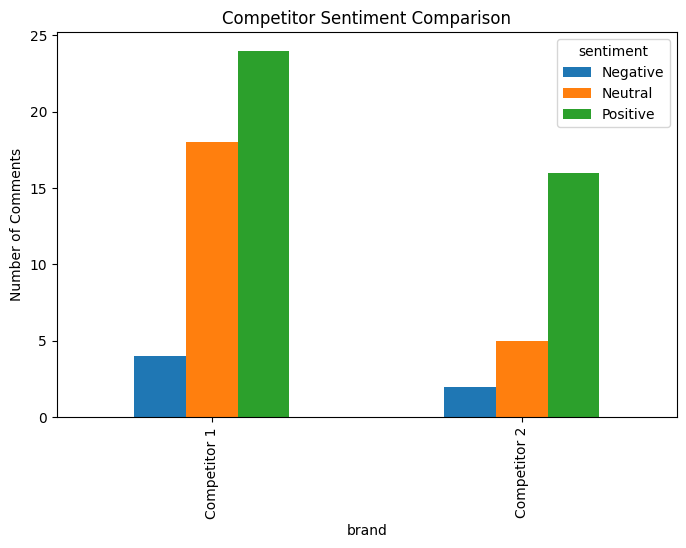

In [8]:
# Daniyal Khan || 221A061

sentiment_counts = df.groupby(["brand","sentiment"]).size().unstack()
print(sentiment_counts)

sentiment_counts.plot(kind="bar", figsize=(8,5))
plt.title("Competitor Sentiment Comparison")
plt.ylabel("Number of Comments")
plt.show()


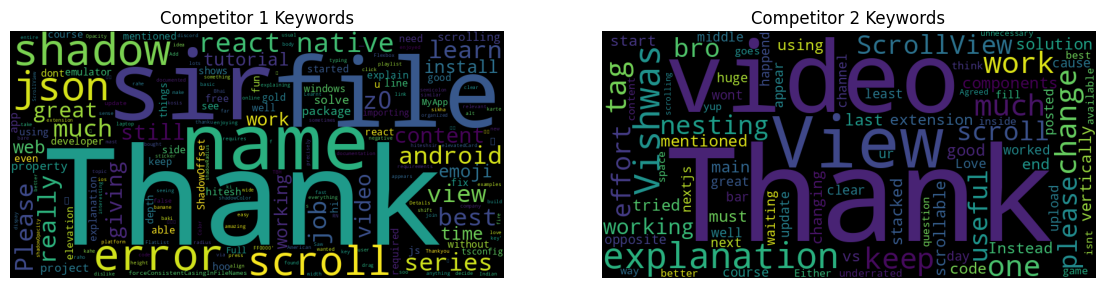

In [9]:
# Daniyal Khan || 221A061

text1 = " ".join(comments1)
text2 = " ".join(comments2)

wordcloud1 = WordCloud(width=800, height=400).generate(text1)
wordcloud2 = WordCloud(width=800, height=400).generate(text2)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.imshow(wordcloud1)
plt.axis("off")
plt.title("Competitor 1 Keywords")
plt.subplot(1,2,2)
plt.imshow(wordcloud2)
plt.axis("off")
plt.title("Competitor 2 Keywords")

plt.show()


In [10]:
# Daniyal Khan || 221A061

print("Competitor 1 Total Comments:", len(comments1))
print("Competitor 2 Total Comments:", len(comments2))


if len(comments1) > len(comments2):
   print("Competitor 1 has higher engagement")


else:
   print("Competitor 2 has higher engagement")

Competitor 1 Total Comments: 46
Competitor 2 Total Comments: 23
Competitor 1 has higher engagement
